<center><h1>NLP - Representación vectorial</center>

<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

## ¿Por qué es necesaria la representación vectorial en NLP?

Nuestro lenguaje es simbólico, se construye a raíz de una secuencia de palabras, o mas a detalle, en base a una secuencia de caracteres/letras, las cuales forman palabras, y a su vez, una secuencia de palabras forman oraciones. Pero, realmente las computadoras no entienden de caracteres, palabras u oraciones. Aquí es donde surge la necesidad de representar ese espacio de palabras en números. Por los cual, en NLP llamamos a esto, una representación vectorial.

<center><img src="./images/vector_representation.png"  height="200"></center>

El poder representar estas palabras/*tokens* de forma numerica, nos permite crear vectores con los cuales podemos entrenar modelos de clasificación, traducción, resumen, generación de texto, etc. O tareas mas cómunes como indexación de texto o búsqueda por medio de su similitud semántica (se podría medir la distancia entre vectores, obteniendo una similitud).

### Métodos de representación vectorial

Existen diferentes métodos de representacoón vectorial, los cuales tienen pros y contras, dependiendo de la tarea que se quiera realizar. En esta clase abordaremos los siguientes tipos de representación vectorial de *tokens*:
- *One-Hot Encoding*
- *Count Vectorizer*
- *TF-IDF*
- *Word Embeddings*
    - Word2Vec
    - Glove
 
**Nota:** En la tercera semana veremos otro tipo de representaciones como lo son los *transformers*



#### One-Hot Encoding

El [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) es una de las técnicas mas básicas de representación vectorial en NLP. Este consiste en convertir palabras en vectores binarios. Estos vectores tienen el tamaño del alfabeto. Donde solo hay un número $1$ en la posición que representa la palabra a codificar, el resto de posiciones se representan con el número $0$. Por ejemplo:

- Dado $m$ como el número de palabras dentro del diccionario $\alpha=  [\alpha_{1}, \alpha_{m}]$. El vector que representa la primera palabra del alfabeto está representado por:
$$ [1, 0, 0, 0 , ... , 0_{m}] $$

##### Ejemplo con diccionario pequeño

Supongamos que nuestro diccionario se conforma de solo las palabras de la imágen inicial $\alpha=[\text{carro, comprar, correr, leer, persona, estudiar, cantar}]$. Este diccionario lo podríamos codificar de la siguiente manera: [sklearn](https://scikit-learn.org/stable/)

In [2]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

tokens = np.array([["carro"], ["comprar"], ["correr"], ["leer"], ["persona"], ["estudiar"], ["cantar"]])

ohe = OneHotEncoder(sparse_output=False)
ohe_vector = ohe.fit_transform(tokens)

print(f"Diccionario de entrenamiento:\n {tokens} \n")
print(f"One-Hot Encoder entrenado: \n {ohe_vector}")

Diccionario de entrenamiento:
 [['carro']
 ['comprar']
 ['correr']
 ['leer']
 ['persona']
 ['estudiar']
 ['cantar']] 

One-Hot Encoder entrenado: 
 [[0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]]


Con el codificador entrenado, podemos obtener dada una palabra dentro del vocabulario, obtener su representación vectorial:

In [2]:
#codifiquemos
ohe.transform([["comprar"]])

array([[0., 0., 1., 0., 0., 0., 0.]])

Si queremos codificar una oración, tenemos que codificar cada token y la matriz resultante sería la entrada de nuestro modelo de AI:

In [3]:
#codifiquemos
sentence = "persona correr comprar"
pro_sent = [[word] for word in sentence.split()]
pro_sent

[['persona'], ['correr'], ['comprar']]

In [4]:
ohe.transform(pro_sent)

array([[0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.]])

- La implementación del *One-Hot Enconding* es bastante sencilla de entender y no cuenta con entrenamiento previo. Lo que hacemos es una transformación de cada palabra a un vector binario que la representa.

- Una de sus principales desventajas es que la dimensionalidad de la matriz crece conforme crece el vocabulario. Entonces para vocabularios de $100.000$ palabras, la matriz tendrá dimensión de $(100.000,100.000)$. Lo que hace que se consuma mucha memoria y procesamiento al aplicar modelos de AI.

- Otra desventaja, es que al ser un vector disperso. Solo tener un $1$ para representar una palabra. Todas las palabras se encuentran a una misma distancia. Por lo cual no es capáz de encontrar relaciones entre las palabras
    - En nuestro ejemplo, de pronto las palabras **Estudiar** y **leer** deberían estár mas próximas, a diferencia de **Estudiar** y **Comprar**

#### Count Vectorizer

En este método de representación vectorial, lo que hacemos es convertir una seríe de corpus en una matrix de tokens. Donde, cada *array* o fila, representa una sentencia. Donde cada posición del *array* hace referencia al número de veces que aparece dicha palabra en la oracion.

Dado un diccionario de palabras $D$ de longitud $n$. Y un corpus $S$, de $m$ sentencias. La matriz de conteo sería:

$$ CV_{(m,n)}$$

Donde la posición $CV_{(0,0)}$ representa cuantas veces aparece la palabra del diccionario $D_{0}$ en la sentencia $S_{0}$

In [5]:
sentence = "este es un ejemplo de un count vectorizer" # OHE -> (7,8) -> (1,7)

##### Ejemplo de implementación con *sklearn*

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = ['este es UN ejemplo de un count vectorizer',
         'segundo ejemplo de corpus en el count vectorizer',
         'tercero tercero tercero']

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(corpus)
print(X_train.toarray())

[[0 1 1 1 0 0 1 1 0 0 2 1]
 [1 1 1 1 1 1 0 0 1 0 0 1]
 [0 0 0 0 0 0 0 0 0 3 0 0]]


Entrenamos el **CountVectorizer** con nuestro corpus

In [4]:
vectorizer.vocabulary_

{'este': 7,
 'es': 6,
 'un': 10,
 'ejemplo': 3,
 'de': 2,
 'count': 1,
 'vectorizer': 11,
 'segundo': 8,
 'corpus': 0,
 'en': 5,
 'el': 4,
 'tercero': 9}

representación vectorial de una nueva sentencia

In [7]:
new_sentence = "segundo corpus"
vectorizer.transform([new_sentence]).toarray()

array([[1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]])

**¿Será bueno que las palabras que se repiten mas tengan mayor peso?**

#### Term Frequency - Inverse Document (TF-IDF)

**TF-IDF** es una técnica que nos ayuda a representar texto de forma vectorial y nos ayuda a resolver el problema de darle mayor peso a plabras frecuentes y que son poco relevantes.

- **TF**: Qué tan frecuente es la palabra en el documento
  $$TF(token, Doc)= \frac{\text{Número de veces que aparece el token en el documento}}{\text{total de tokens en el documento}}$$
- **IDF**: Qué tan rara es la palabra en el corpus total
  $$IDF(token) = log(\frac{\text{Número de documentos}}{\text{Número de documentos donde aparece el token}})$$
- **TF-IDF:**
  $$TF-IDF(token, Doc) = TF(token,Doc)*IDF(token)$$

##### Ejemplo de implementación con *sklearn*

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidv = TfidfVectorizer()
X_train_tfidv = tfidv.fit_transform(corpus)
print(X_train_tfidv.toarray())

[[0.         0.26376638 0.26376638 0.26376638 0.         0.
  0.34682109 0.34682109 0.         0.         0.69364217 0.26376638]
 [0.39798027 0.30267425 0.30267425 0.30267425 0.39798027 0.39798027
  0.         0.         0.39798027 0.         0.         0.30267425]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.        ]]


## ¿Es computacionalmente viable que nuestro vector sea del tamaño de nuesto vocabulario?

#### Word Embeddings

A igual que los *One-Hot Enconder*, los ***Word Embeddings*** son representaciones vectoriales de palabras dentro de un determinado espacio. Pero, **¿Qué los hace mas robustos que el One-Hot Encoder?**

Resulta que los *word Embeddings* son vectores de baja dimensionalidad, es decir, el tamaño de dimensión del vector no depende del número de tokens del vocabulario. Lo cual, como primer punto, lo hace super interesante. Así mismo, este vector es un vector denso, donde realmente se devuelven una seríe de valores en un espacio $n$-dimensional. Donde lo que se representa, es la similitud de dicha palabra con las demás. Por lo cual, así también resolvemos el problema de la relación entre palabras que pesenta el *One-Hot Encoder*.

<center><img src="./images/word_embeddings.png"  height="200"></center>

En otras palabras, un vector de *word embedding* de una palabra/token, repeseta su posición en un espacio $n$-dimensional, siendo que las palabras mas cercanas a esa posición, son palabras relacionadas al token.

##### ¿Cómo creamos un word embedding? 

Una de las formas mas usuales de crear un *word embedding* es mediante una red neuronal. Supongamos que tenemos un corpus para una tarea de clasificación. En el cual, dadas ciertas palabras de entrada, requerimos predecir una palabra objetivo (Esto se conoce como **CBOW** - **Continuous Bag of Words**. Una vez entrenada la red neuronal, su capa oculta (vector de pesos), se le considera un *word embedding*, ya que estos pesos son los que se ajustaron para entender la relación de determinados contextos y palabras.

<center><img src="./images/red_neuronal.png"  height="200"></center>

##### Implementación de word embedding

Para esta implementación utilizaremos la librería [Gensim](https://radimrehurek.com/gensim/index.html). La cual nos brinda carga una serie de modelos de *word embeddings* pre-entrenados. Para este ejemplo, volveremos a usar el corpus CESS_ESP visto en la primera semana.

In [10]:
from nltk.corpus import cess_esp

def load_sentences():
    return cess_esp.sents()

cess_sents = load_sentences()

print(f" cantidad de oraciones: {len(cess_sents)}")

 cantidad de oraciones: 6030


In [11]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python3 -m pip install --upgrade pip


Entrenamos el modelo con nuestro corpus:

In [12]:
from gensim.models import Word2Vec
from time import time

tic = time()
model = Word2Vec(sentences=cess_sents, vector_size=250,
                workers=3, min_count=5, epochs=15, compute_loss=True)
toc = time()
print(f"tiempo de ejecución: {(toc-tic)/60}")

tiempo de ejecución: 2.642406638463338


Con el modelo entrenado, lo que podemos hacer es a partir de una palabra, generar su vector o calcular similitudes

In [13]:
word = cess_sents[16][6]
print(f"palabra: {word}")
model.wv[word]

palabra: pertenece


array([ 0.00108604, -0.00547876,  0.10136624,  0.06769782, -0.12385792,
       -0.04895715, -0.01117971,  0.13360643, -0.03267053, -0.01455845,
       -0.03233347, -0.04017202,  0.01161225,  0.02001143, -0.0098112 ,
       -0.02271963, -0.03907251,  0.01697461, -0.06308696, -0.02403241,
       -0.0633662 ,  0.03517928,  0.05468418, -0.00872694,  0.01751715,
        0.03822219,  0.00564653, -0.03553613, -0.17665221, -0.0049375 ,
       -0.01683434,  0.01738593,  0.0333947 ,  0.00399299,  0.09021638,
       -0.05033967,  0.19768903, -0.08020441, -0.05107736, -0.04406212,
       -0.07212754,  0.04266384, -0.05675104,  0.01221036,  0.07451623,
       -0.06595621,  0.04126228, -0.01964023,  0.10066016,  0.03710016,
       -0.09992877,  0.08514868, -0.07789709, -0.07300003,  0.01655773,
       -0.11439592,  0.05843128, -0.02209735, -0.05923612, -0.06252415,
        0.04940968, -0.02259365,  0.02638708,  0.00981759,  0.01351985,
       -0.04322058,  0.02955403,  0.0568451 ,  0.0949823 , -0.04

**Nota:** Recordar que aquí no estamos aplicando el pre-procesamiento del corpus, factor clave para obtener mejores resultados.

Con el modelo entrenado, podemos computar la similaridad entre dos palabras (basandonos en la distancia del coseno)

In [15]:
model.wv.similar_by_word("presidente", topn=10)

[('ministro', 0.9661982655525208),
 ('general', 0.9294919371604919),
 ('ex', 0.9166925549507141),
 ('secretario', 0.9084111452102661),
 ('director', 0.8987272381782532),
 ('jefe', 0.8842687606811523),
 ('portavoz', 0.8829569816589355),
 ('primer', 0.8822609782218933),
 ('vicepresidente', 0.8763479590415955),
 ('anunció', 0.8673946857452393)]

Podemos observar nuestras palabras/tokens del vocabulario

In [22]:
model.wv.similarity("pertenece", "Gobierno")

0.6731629

#### ¿Cómo podemos ver la similitud en el espacio vectorial?

Lo que podemos hacer es realizar una reducción de la dimensionalidad del vector (mediante PCA), y graficarlo por ejemplo en 2 dimensiones:

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [24]:
len(model.wv.key_to_index.keys())

4039

In [25]:
vectors = model.wv[model.wv.key_to_index]
print(f"Cantidad de palabras: {len(vectors)}")
vectors[0].shape

Cantidad de palabras: 4039


(250,)

In [26]:
pca_vectors = pca.fit_transform(vectors)
pca_vectors.shape

(4039, 2)

In [27]:
words = np.asarray(list(model.wv.key_to_index), dtype=str)
words

array([',', 'de', 'la', ..., 'ricos', 'Tengo', 'inmediatos'], dtype='<U47')

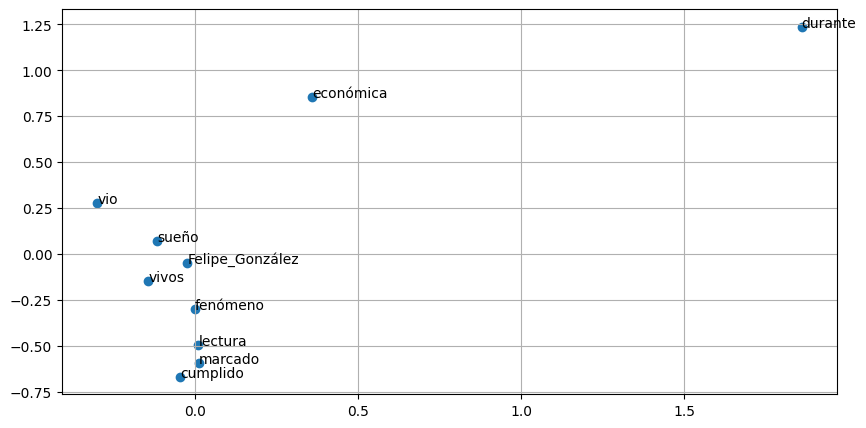

In [31]:
from matplotlib import pyplot as plt

random_idx = np.random.choice(range(len(pca_vectors)), 10)

plt.figure(figsize=(10,5))
plt.scatter(pca_vectors[random_idx, 0], pca_vectors[random_idx, 1])
for i, word in zip(random_idx, words[random_idx]):
    plt.annotate(word, xy=(pca_vectors[i, 0], pca_vectors[i, 1]))
plt.grid();

Generamos la gráfica del espacio vectorial

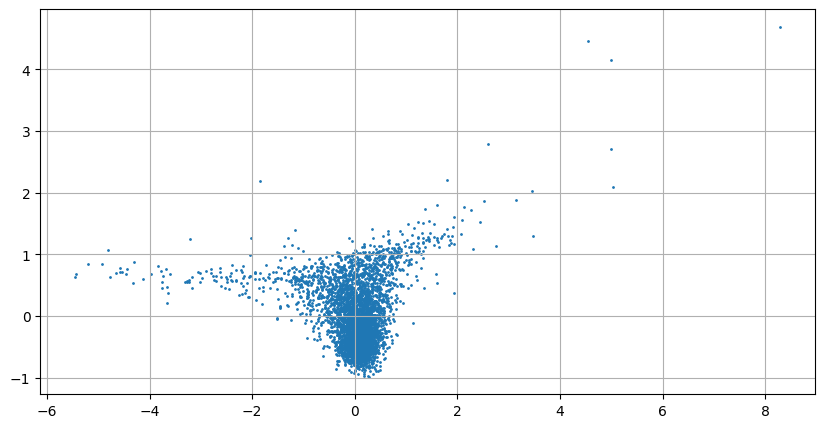

In [32]:
plt.figure(figsize=(10,5))
plt.scatter(pca_vectors[:, 0], pca_vectors[:, 1], s=1);
plt.grid();

### Modelos pre-entrenados 

Hasta este punto, logramos representar texto en vectores empleando diferentes métodos. A continuación, utilizaremos modelos de *embeddings* pre-entrenados. Esto se conoce como *transfer-learning*. Consiste en tomar un modelo previamente entrenado con un corpus de gran volumen, y adaptarlo a una tarea en específica.

En esta oportunidad utilizaremos [**fasttext**](https://fasttext.cc/), una librería para la clasificación de texto. Cuenta con vectores para [157 lenguas](https://fasttext.cc/docs/en/crawl-vectors.html), siendo entrenado con corpus extraídos de *wikipedia* y *common crawl*. Todos estos modelos fueron entrenado con la técnica **CBOW**

In [1]:
# descargamos el vector de pesos
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz

--2026-02-06 18:01:29--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz
Resolviendo dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.144.104, 54.230.144.2, 54.230.144.118, ...
Conectando con dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)[54.230.144.104]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 1285580896 (1,2G) [binary/octet-stream]
Guardando como: ‘cc.es.300.vec.gz’

cc.es.300.vec.gz    100%[===================>]   1,20G  26,6MB/s    en 43s     

2026-02-06 18:02:13 (28,4 MB/s) - ‘cc.es.300.vec.gz’ guardado [1285580896/1285580896]



In [36]:
# se descomprime el vector
!gunzip cc.es.300.vec.gz

gzip: cc.es.300.vec already exists; do you wish to overwrite (y or n)? ^C


Cargamos el vector entrenado:

In [39]:
from gensim.models import KeyedVectors
modelo_ft = KeyedVectors.load_word2vec_format("cc.es.300.vec")

In [43]:
modelo_ft.most_similar("presidente")

[('Presidente', 0.8553783297538757),
 ('vicepresidente', 0.8025380373001099),
 ('ex-presidente', 0.7885878682136536),
 ('expresidente', 0.7720528244972229),
 ('presidnete', 0.7419165372848511),
 ('mandatario', 0.7122958898544312),
 ('Vicepresidente', 0.7089223861694336),
 ('presidente.El', 0.7074533700942993),
 ('presidencia', 0.7068176865577698),
 ('vice-presidente', 0.702968418598175)]

Una forma de obtener una primera impresión de la calidad de nuestro modelo es generando las palabras mas similares de unas determinadas palabras:

In [25]:
words = ["cantar", "caminar", "reir", "programar"]
most_dict = {}
for word in words:
    most_dict[word] = [s_word_tuple[0] for s_word_tuple in modelo_ft.most_similar(word)]

print(most_dict)

{'cantar': ['entonar', 'cantarla', 'cantarnos', 'cantarlo', 'cantarlas', 'cantando', 'cantarle', 'canturrear', 'cantarse', 'canta'], 'caminar': ['Caminar', 'andar', 'caminarse', 'caminando', 'caminarlo', 'trotar', 'caminarte', 'caminarla', 'caminarlos', 'caminado'], 'reir': ['reír', 'reirme', 'reirse', 'sonreir', 'reir.', 'llorar', 'reír.Y', 'reírme', 'reirnos', 'carcajear'], 'programar': ['Programar', 'programarlo', 'programarle', 'programarla', 'programando', 'programarlos', 'programarlas', 'progamar', 'programarse', 'programarte']}


##### ¿Cómo podemos comparar documentos?

Una forma bastante sencilla de comparar dos documentos es mediante el promedio de *embeddings*:

A, B -> simil cos -> umbral

A = "prueba de funcionamiento"

B = "los carros estacionado en el parqueadero"

In [26]:
def doc_to_vector(tokens, model):
    embeddings = [model[word] for word in tokens if word in model]
    if not embeddings:
        return np.zeros(model.vector_size)
    return np.mean(embeddings, axis=0)

doc_1 = doc_to_vector(cess_sents[1], modelo_ft)
doc_2 = doc_to_vector(cess_sents[100], modelo_ft)
print(f"oración 1: {cess_sents[1]} \n")
print(f"oración 2: {cess_sents[100]}")

oración 1: ['Una', 'portavoz', 'de', 'EDF', 'explicó', 'a', 'EFE', 'que', 'el', 'proyecto', 'para', 'la', 'construcción', 'de', 'Altamira_2', ',', 'al', 'norte', 'de', 'Tampico', ',', 'prevé', 'la', 'utilización', 'de', 'gas', 'natural', 'como', 'combustible', 'principal', 'en', 'una', 'central', 'de', 'ciclo', 'combinado', 'que', 'debe', 'empezar', 'a', 'funcionar', 'en', 'mayo_del_2002', '.'] 

oración 2: ['1996', '-Fpt-', 'La_Declaración_de_Viña_del_Mar', ',', 'dedicada', 'a', 'la', '"', 'Gobernabilidad', 'y', 'la', 'democracia', '"', ',', 'reafirmó', 'el', 'compromiso', 'con', 'el', 'sistema', 'democrático', ',', 'el', 'Estado_de_Derecho', ',', 'el', 'pluralismo', 'político', ',', 'los', 'derechos_humanos', 'y', 'las', 'libertades', 'fundamentales', 'como', '"', 'marco', 'de', 'la', 'gobernabilidad', 'para', 'una', 'democracia', 'eficiente', 'y', 'participativa', '"', '.']


In [27]:
doc_1.shape

(300,)

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_cosine_simil(word1, word2):
    return cosine_similarity([word1], [word2])

In [29]:
compute_cosine_simil(doc_1, doc_2)

array([[0.88841146]], dtype=float32)

Representemos en 2D los embbeddings

In [30]:
from sklearn.decomposition import PCA

pca_pre = PCA(n_components=2)

In [31]:
#vectors_pre = modelo_ft.get_vector(list(modelo_ft.key_to_index)
vectors_pre = [modelo_ft.get_vector(word) for word in list(modelo_ft.key_to_index)]
print(f"Cantidad de palabras: {len(vectors_pre)}")
vectors_pre[0].shape

Cantidad de palabras: 2000000


(300,)

In [44]:
pca_vectors_pre = pca_pre.fit_transform(vectors_pre[:200])

In [46]:
words_pre = np.array(list(modelo_ft.key_to_index)[:200])
print(words_pre)

['de' ',' '.' 'la' 'y' 'en' 'que' 'el' '</s>' 'a' 'los' ':' '"' 'del' 'un'
 ')' 'se' 'con' 'por' 'las' '(' 'para' 'una' 'es' 'no' 'su' 'al' 'como'
 'lo' '/' 'más' 'El' 'o' "'" 'La' '!' '|' '?' 'me' 'En' '...' '-' 'sus'
 'este' 'pero' 'ha' 'esta' ';' '“' '_' '”' 'si' 'sobre' '¿' 'fue' 'son'
 'le' 'muy' 'ser' 'ya' 'tu' 'todo' '1' 'entre' 'te' 'mi' 'Los' '%' 'sin'
 'también' 'está' 'desde' 'años' 'puede' 'dos' '2' 'cuando' 'hasta' 'nos'
 'tiene' 'todos' 'A' 'No' 'Y' 'donde' 'parte' '3' 'hay' 'vez' 'han' 'e'
 'porque' '#' '…' 'año' '¡' 'Se' 'bien' 'tiempo' 'así' 'cada' 'uno' 'DE'
 'hacer' 'Por' '»' 'era' 'forma' 'Las' 'hace' 'vida' 'mismo' 'día' '10'
 'Es' 'otros' 'mejor' '4' 'ver' '*' '5' 'De' '–' 'sido' 'gran' 'durante'
 'mucho' 'mundo' 'Si' 'ni' 'personas' 'tanto' 'Para' 'yo' 'siempre' 'solo'
 'ese' 'eso' 'lugar' 'otro' 'menos' 'información' 'poco' 'nuevo' 'había'
 'Más' 'Un' 'algo' 'primera' 'qué' 'están' 'después' 'trabajo' 'cuenta'
 '12' 'todas' 'tan' 'mayor' 'ciudad' 'estos' '2017' 

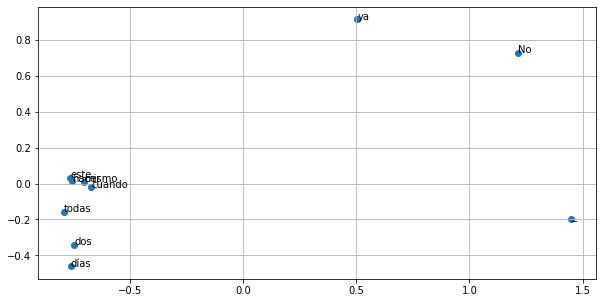

In [49]:
from matplotlib import pyplot as plt

random_idx = np.random.choice(range(len(pca_vectors_pre[:200])), 10)
plt.figure(figsize=(10,5))
plt.scatter(pca_vectors_pre[random_idx, 0], pca_vectors_pre[random_idx, 1])
for i, word in zip(random_idx, words_pre[random_idx]):
    plt.annotate(word, xy=(pca_vectors_pre[i, 0], pca_vectors_pre[i, 1]))
plt.grid();

## Documentación

- One-Hot Encoding: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
- https://code.google.com/archive/p/word2vec/
- https://www.tensorflow.org/text/guide/word_embeddings?hl=es-419